# Vision Transformer - Fraud Type Classification - 15K Dataset

**Phase 2 of the forgery detection pipeline.**

Given a document already classified as FAKE by Phase 1, this model classifies the fraud type:
- **Class 0**: face_morphing
- **Class 1**: face_replacement

## Dataset
- Filtered from 15K dataset to **fakes only**
- Train: ~6,000 | Val: ~750 | Test: ~750
- Balanced ~50/50 morphing vs replacement

## Architecture (same proven recipe as binary model)

| Setting | Value |
|---------|-------|
| **Model** | ViT-Small (384-dim) |
| **Loss** | Focal Loss (gamma=2.0) |
| **Augmentation** | Light (preserve forgery artifacts) |
| **Training** | 3-stage gradual unfreezing |
| **Head** | MLP (LayerNorm → Linear → GELU → Dropout → Linear) |
| **TTA** | 4 augmented views |

**Old multi-task baseline to beat:** 93.2% in-dataset, 65.3% out-of-dataset

## Setup

In [1]:
import os
import sys

project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/roy-siftt/final-project


In [2]:
%pip install -q timm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## Load Data (Fakes Only from 15K Dataset)

In [4]:
data_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit_15k/data"
dataset_root = "/Users/roy-siftt/final-project/datasets/drivers_license_15k"

# Load full splits and filter to fakes only
fraud_type_map = {'face_morphing': 0, 'face_replacement': 1}

train_df_full = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df_full = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df_full = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Filter to fakes only
train_df = train_df_full[train_df_full['is_fake'] == 1].reset_index(drop=True)
val_df = val_df_full[val_df_full['is_fake'] == 1].reset_index(drop=True)
test_df = test_df_full[test_df_full['is_fake'] == 1].reset_index(drop=True)

# Add numeric fraud type label
train_df['fraud_label'] = train_df['fraud_type'].map(fraud_type_map)
val_df['fraud_label'] = val_df['fraud_type'].map(fraud_type_map)
test_df['fraud_label'] = test_df['fraud_type'].map(fraud_type_map)

print(f"Fakes-only dataset:")
print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)}")

print(f"\nTrain balance:")
for ft, count in train_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(train_df)*100:.1f}%)")

print(f"\nVal balance:")
for ft, count in val_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(val_df)*100:.1f}%)")

print(f"\nTest balance:")
for ft, count in test_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(test_df)*100:.1f}%)")

Fakes-only dataset:
  Train: 6000 | Val: 750 | Test: 750
  Total: 7500

Train balance:
  face_morphing: 3010 (50.2%)
  face_replacement: 2990 (49.8%)

Val balance:
  face_morphing: 384 (51.2%)
  face_replacement: 366 (48.8%)

Test balance:
  face_replacement: 394 (52.5%)
  face_morphing: 356 (47.5%)


## Focal Loss

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal Loss defined (gamma=2.0)")

Focal Loss defined (gamma=2.0)


## Lighter Augmentation Strategy

Same as binary model: preserve forgery artifacts, minimal blur/noise, NO CoarseDropout.

In [6]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=0,
        p=0.5
    ),
    A.Perspective(
        scale=(0.02, 0.05),
        p=0.2
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.1
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

tta_transforms = [
    val_test_transform,
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(0.95, 0.95), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(1.05, 1.05), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

print("Augmentation strategy:")
print("  - LIGHTER transforms to preserve forgery artifacts")
print("  - NO CoarseDropout")
print("  - Minimal blur/noise")
print("  - TTA: 4 augmented views")

Augmentation strategy:
  - LIGHTER transforms to preserve forgery artifacts
  - NO CoarseDropout
  - Minimal blur/noise
  - TTA: 4 augmented views


## Dataset Class

In [7]:
class FraudTypeDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform is not None:
            transformed = self.transform(image=img_np)
            img = transformed['image']

        label = int(row['fraud_label'])  # 0=morphing, 1=replacement
        return img, torch.tensor(label, dtype=torch.long)

# Create datasets
train_dataset = FraudTypeDataset(train_df, dataset_root, train_transform)
val_dataset = FraudTypeDataset(val_df, dataset_root, val_test_transform)
test_dataset = FraudTypeDataset(test_df, dataset_root, val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Batch size: 64")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Batch size: 64
Train batches: 93 | Val batches: 12 | Test batches: 12


## ViT-Small Model with MLP Head

In [8]:
class ViTFraudTypeClassifier(nn.Module):
    def __init__(self, model_name='vit_small_patch16_224', num_classes=2, pretrained=True, dropout=0.1):
        super(ViTFraudTypeClassifier, self).__init__()
        
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        num_features = self.vit.embed_dim
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, num_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_features // 2, num_classes)
        )
        
        print(f"Model: {model_name}")
        print(f"  - Embedding dim: {num_features}")
        print(f"  - MLP head: {num_features} -> {num_features//2} -> {num_classes}")
        print(f"  - Classes: 0=face_morphing, 1=face_replacement")
        print(f"  - Dropout: {dropout}")
        print(f"  - Total params: {sum(p.numel() for p in self.parameters()):,}")
        
    def forward(self, x):
        features = self.vit(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone FROZEN")
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")
    
    def unfreeze_last_n_blocks(self, n=4):
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        for block in self.vit.blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        for param in self.vit.norm.parameters():
            param.requires_grad = True
        print(f"Last {n} transformer blocks UNFROZEN")

# Create model
model = ViTFraudTypeClassifier(
    model_name='vit_small_patch16_224',
    num_classes=2,
    pretrained=True,
    dropout=0.1
).to(device)

Model: vit_small_patch16_224
  - Embedding dim: 384
  - MLP head: 384 -> 192 -> 2
  - Classes: 0=face_morphing, 1=face_replacement
  - Dropout: 0.1
  - Total params: 21,740,738


## Training with 3-Stage Unfreezing + OneCycleLR

1. **Stage 1 (10 epochs):** Train only classifier head
2. **Stage 2 (15 epochs):** Unfreeze last 4 transformer blocks
3. **Stage 3 (25 epochs):** Full fine-tuning with lower LR

In [9]:
criterion = FocalLoss(alpha=1.0, gamma=2.0)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = None
best_epoch = 0
max_grad_norm = 1.0

def evaluate(loader, use_tta=False):
    model.eval()
    
    if not use_tta:
        total, correct = 0, 0
        loss_total = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss_total += loss.item()
                
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return {
            'acc': correct / total,
            'loss': loss_total / len(loader),
            'preds': all_preds,
            'labels': all_labels
        }
    else:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in loader:
                batch_probs = []
                imgs_np = imgs.numpy().transpose(0, 2, 3, 1)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                imgs_np = (imgs_np * std + mean) * 255
                imgs_np = imgs_np.astype(np.uint8)
                
                for tta_transform in tta_transforms:
                    tta_imgs = []
                    for img in imgs_np:
                        transformed = tta_transform(image=img)
                        tta_imgs.append(transformed['image'])
                    tta_batch = torch.stack(tta_imgs).to(device)
                    outputs = model(tta_batch)
                    probs = F.softmax(outputs, dim=1)
                    batch_probs.append(probs.cpu())
                
                avg_probs = torch.stack(batch_probs).mean(dim=0)
                all_probs.append(avg_probs)
                all_labels.extend(labels.numpy())
        
        all_probs = torch.cat(all_probs, dim=0)
        all_preds = all_probs.argmax(dim=1).numpy()
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        
        return {
            'acc': correct / total,
            'loss': 0.0,
            'preds': all_preds.tolist(),
            'labels': all_labels.tolist()
        }

def train_one_epoch(train_loader, optimizer, scheduler, epoch_desc):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=epoch_desc)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    return total_loss / len(train_loader)

print("Training functions defined")
print(f"  - Focal Loss (gamma=2.0)")
print(f"  - TTA evaluation available")

Training functions defined
  - Focal Loss (gamma=2.0)
  - TTA evaluation available


In [10]:
# ============================================
# STAGE 1: Train Classifier Head Only
# ============================================
print("\n" + "="*70)
print("STAGE 1: Training Classifier Head (10 epochs)")
print("="*70)

model.freeze_backbone()

stage1_epochs = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer, 
    max_lr=1e-3,
    epochs=stage1_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S1 Epoch {epoch+1}/{stage1_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage1_end = len(history['train_loss'])
print(f"\nStage 1 complete. Best val acc: {best_val_acc:.4f}")


STAGE 1: Training Classifier Head (10 epochs)
Backbone FROZEN


S1 Epoch 1/10: 100%|██████████| 93/93 [02:04<00:00,  1.34s/it, loss=0.1555, lr=1.00e-03]


  Train Acc: 0.6746 | Val Acc: 0.7013 | Val Loss: 0.1433
  -> New best: 0.7013


S1 Epoch 2/10: 100%|██████████| 93/93 [02:01<00:00,  1.30s/it, loss=0.1687, lr=9.69e-04]


  Train Acc: 0.7372 | Val Acc: 0.7933 | Val Loss: 0.1198
  -> New best: 0.7933


...

  Train Acc: 0.7823 | Val Acc: 0.8360 | Val Loss: 0.0972
  -> New best: 0.8360


S1 Epoch 9/10: 100%|██████████| 93/93 [01:58<00:00,  1.28s/it, loss=0.1216, lr=2.95e-05]


  Train Acc: 0.7742 | Val Acc: 0.8427 | Val Loss: 0.0951
  -> New best: 0.8427


S1 Epoch 10/10: 100%|██████████| 93/93 [01:59<00:00,  1.28s/it, loss=0.1147, lr=7.52e-09]


  Train Acc: 0.7781 | Val Acc: 0.8520 | Val Loss: 0.0945
  -> New best: 0.8520

Stage 1 complete. Best val acc: 0.8520


In [11]:
# ============================================
# STAGE 2: Unfreeze Last 4 Transformer Blocks
# ============================================
print("\n" + "="*70)
print("STAGE 2: Unfreezing Last 4 Blocks (15 epochs)")
print("="*70)

model.unfreeze_last_n_blocks(n=4)

stage2_epochs = 15
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-5,
    epochs=stage2_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S2 Epoch {epoch+1}/{stage2_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage1_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage2_end = len(history['train_loss'])
print(f"\nStage 2 complete. Best val acc: {best_val_acc:.4f}")


STAGE 2: Unfreezing Last 4 Blocks (15 epochs)
Last 4 transformer blocks UNFROZEN


S2 Epoch 1/15: 100%|██████████| 93/93 [02:09<00:00,  1.39s/it, loss=0.1142, lr=3.83e-05]


  Train Acc: 0.7949 | Val Acc: 0.8213 | Val Loss: 0.1018


S2 Epoch 2/15: 100%|██████████| 93/93 [02:08<00:00,  1.39s/it, loss=0.1096, lr=4.98e-05]


  Train Acc: 0.8451 | Val Acc: 0.8907 | Val Loss: 0.0713
  -> New best: 0.8907


...

  Train Acc: 0.9351 | Val Acc: 0.9533 | Val Loss: 0.0356
  -> New best: 0.9533


S2 Epoch 14/15: 100%|██████████| 93/93 [02:09<00:00,  1.40s/it, loss=0.0400, lr=6.60e-07]


  Train Acc: 0.9367 | Val Acc: 0.9560 | Val Loss: 0.0351
  -> New best: 0.9560


S2 Epoch 15/15: 100%|██████████| 93/93 [02:08<00:00,  1.38s/it, loss=0.0271, lr=2.78e-10]


  Train Acc: 0.9350 | Val Acc: 0.9560 | Val Loss: 0.0353

Stage 2 complete. Best val acc: 0.9560


In [12]:
# ============================================
# STAGE 3: Full Fine-Tuning
# ============================================
print("\n" + "="*70)
print("STAGE 3: Full Fine-Tuning (25 epochs)")
print("="*70)

model.unfreeze_backbone()

stage3_epochs = 25
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-5,
    epochs=stage3_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,
    anneal_strategy='cos'
)

patience = 8
patience_counter = 0

for epoch in range(stage3_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S3 Epoch {epoch+1}/{stage3_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage2_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc + 0.002:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {total_epoch}")
            break

print(f"\nStage 3 complete. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


STAGE 3: Full Fine-Tuning (25 epochs)
Backbone UNFROZEN


S3 Epoch 1/25: 100%|██████████| 93/93 [02:35<00:00,  1.68s/it, loss=0.0357, lr=9.14e-06]


  Train Acc: 0.9241 | Val Acc: 0.9427 | Val Loss: 0.0410


S3 Epoch 2/25: 100%|██████████| 93/93 [02:31<00:00,  1.63s/it, loss=0.0573, lr=9.97e-06]


  Train Acc: 0.9383 | Val Acc: 0.9600 | Val Loss: 0.0307
  -> New best: 0.9600


...

  Train Acc: 0.9736 | Val Acc: 0.9760 | Val Loss: 0.0198


S3 Epoch 13/25: 100%|██████████| 93/93 [02:30<00:00,  1.62s/it, loss=0.0336, lr=5.08e-06]


  Train Acc: 0.9726 | Val Acc: 0.9573 | Val Loss: 0.0393


S3 Epoch 14/25: 100%|██████████| 93/93 [02:30<00:00,  1.61s/it, loss=0.0324, lr=4.42e-06]


  Train Acc: 0.9758 | Val Acc: 0.9760 | Val Loss: 0.0227
  Early stopping at epoch 39

Stage 3 complete. Best val acc: 0.9760 at epoch 31


In [13]:
# Load best model
print("\n" + "="*70)
print("Loading Best Model")
print("="*70)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
else:
    print("Warning: No best model state saved")


Loading Best Model
Loaded best model from epoch 31
Best validation accuracy: 0.9760


## Final Evaluation

In [14]:
print("\n" + "="*70)
print("FINAL TEST EVALUATION - FRAUD TYPE")
print("="*70)

test_metrics = evaluate(test_loader, use_tta=False)
print(f"\nTest Accuracy (standard): {test_metrics['acc']:.4f}")

print("\nRunning Test-Time Augmentation (4 views)...")
test_metrics_tta = evaluate(test_loader, use_tta=True)
print(f"Test Accuracy (with TTA): {test_metrics_tta['acc']:.4f}")

print(f"\n{'='*50}")
print("COMPARISON WITH OLD MULTI-TASK MODEL")
print(f"{'='*50}")
print(f"Old multi-task (in-dataset):    93.20%")
print(f"This model (standard):          {test_metrics['acc']*100:.2f}%")
print(f"This model (with TTA):          {test_metrics_tta['acc']*100:.2f}%")
print(f"{'='*50}")


FINAL TEST EVALUATION - FRAUD TYPE

Test Accuracy (standard): 0.9467

Running Test-Time Augmentation (4 views)...
Test Accuracy (with TTA): 0.9560

COMPARISON WITH OLD MULTI-TASK MODEL
Old multi-task (in-dataset):    93.20%
This model (standard):          94.67%
This model (with TTA):          95.60%


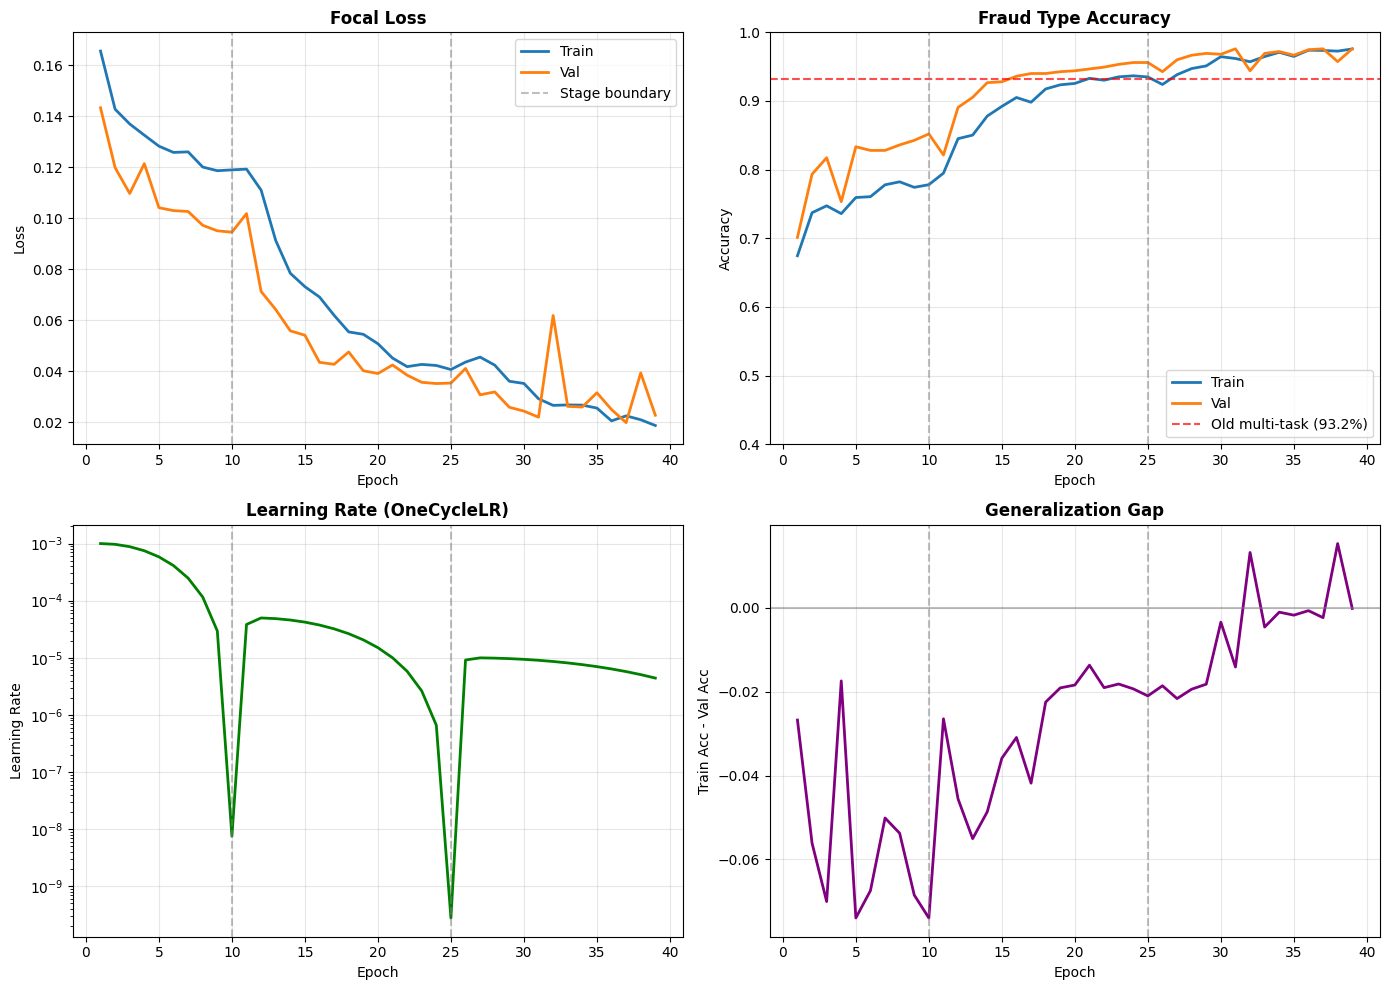

In [15]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], label='Val', linewidth=2)
axes[0, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5, label='Stage boundary')
axes[0, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Focal Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], label='Val', linewidth=2)
axes[0, 1].axhline(y=0.932, color='red', linestyle='--', alpha=0.7, label='Old multi-task (93.2%)')
axes[0, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Fraud Type Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

axes[1, 0].plot(epochs, history['lr'], linewidth=2, color='green')
axes[1, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Generalization Gap', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/vit_15k/training_curves_fraud_type.png', dpi=150)
plt.show()


CONFUSION MATRIX


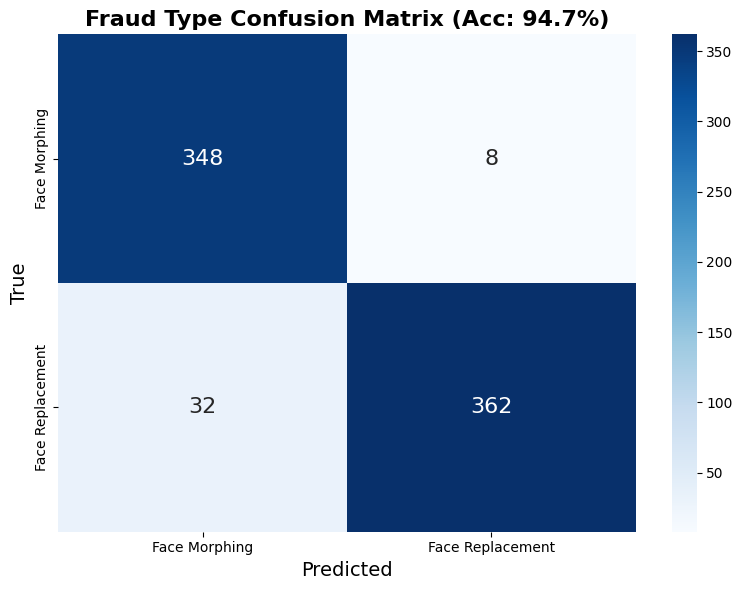


Classification Report:
                  precision    recall  f1-score   support

   Face Morphing       0.92      0.98      0.95       356
Face Replacement       0.98      0.92      0.95       394

        accuracy                           0.95       750
       macro avg       0.95      0.95      0.95       750
    weighted avg       0.95      0.95      0.95       750



In [16]:
# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
labels = ['Face Morphing', 'Face Replacement']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title(f'Fraud Type Confusion Matrix (Acc: {test_metrics["acc"]*100:.1f}%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/drivers_license_forgery/vit_15k/confusion_matrix_fraud_type.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

## Save Model

In [17]:
import pickle
import shutil

notebook_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit_15k"
model_path = os.path.join(notebook_dir, "vit_fraud_type_15k.pth")

# Check disk space
disk = shutil.disk_usage(notebook_dir)
free_gb = disk.free / (1024**3)
print(f"Disk space available: {free_gb:.1f} GB")

if free_gb < 0.5:
    print("WARNING: Low disk space! Saving to /tmp/ instead")
    model_path = "/tmp/vit_fraud_type_15k.pth"

try:
    if best_model_state is not None:
        cpu_state = {k: v.cpu() for k, v in best_model_state.items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
        print(f"  Best epoch: {best_epoch}")
        print(f"  Best val acc: {best_val_acc:.4f}")
        print(f"  Test acc: {test_metrics['acc']:.4f}")
        print(f"  Test acc (TTA): {test_metrics_tta['acc']:.4f}")
    else:
        cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Save failed: {e}")
    fallback = "/tmp/vit_fraud_type_15k.pth"
    cpu_state = {k: v.cpu() for k, v in (best_model_state or model.state_dict()).items()}
    torch.save(cpu_state, fallback)
    print(f"Saved to fallback: {fallback}")

# Save training history
history_path = os.path.join(notebook_dir, "training_history_fraud_type.pkl")
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"Training history saved to: {history_path}")

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {size_mb:.1f} MB")

Disk space available: 40.8 GB
Model saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit_15k/vit_fraud_type_15k.pth
  Best epoch: 31
  Best val acc: 0.9760
  Test acc: 0.9467
  Test acc (TTA): 0.9560
Training history saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit_15k/training_history_fraud_type.pkl
Model file size: 83.0 MB


## Out-of-Dataset Evaluation (test_samples.json — fakes only)

In [18]:
import json

# Auto-reload transforms if needed
if 'tta_transforms' not in dir():
    print("Reloading transforms...")
    tta_transforms = [
        A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(0.95, 0.95), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(1.05, 1.05), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
    ]

fraud_type_map_eval = {'face_morphing': 0, 'face_replacement': 1}
fraud_type_names = {0: 'Face Morphing', 1: 'Face Replacement'}

def predict_single(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for transform in tta_transforms:
            transformed = transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    
    avg_probs = torch.stack(all_probs).mean(dim=0)
    pred = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred].item()
    
    return pred, confidence

# Load test samples and filter to fakes only
samples_path = os.path.join(project_root, "notebooks/drivers_license_forgery/vit/test_samples.json")
with open(samples_path) as f:
    all_samples = json.load(f)

# Only evaluate on fake samples
samples = [s for s in all_samples if s['is_fake'] == 1]

print(f"\n{'='*70}")
print(f"OUT-OF-DATASET FRAUD TYPE EVALUATION ({len(samples)} fake samples)")
print(f"{'='*70}")
print(f"  face_morphing: {sum(1 for s in samples if s['fraud_type'] == 'face_morphing')}")
print(f"  face_replacement: {sum(1 for s in samples if s['fraud_type'] == 'face_replacement')}")

true_labels, pred_labels, details = [], [], []
skipped = 0

for s in tqdm(samples, desc="Evaluating"):
    img_path = os.path.join(project_root, s['path'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    true_idx = fraud_type_map_eval[s['fraud_type']]
    pred_idx, confidence = predict_single(img_path, model, device)
    
    pred_name = fraud_type_names[pred_idx]
    true_name = fraud_type_names[true_idx]

    true_labels.append(true_idx)
    pred_labels.append(pred_idx)
    details.append({
        'path': s['path'],
        'country': s['country'],
        'fraud_type': s['fraud_type'],
        'true': true_name,
        'pred': pred_name,
        'confidence': confidence,
        'correct': pred_idx == true_idx
    })

if skipped:
    print(f"Skipped {skipped} (file not found)")

# Results
correct = sum(d['correct'] for d in details)
total = len(details)
ood_accuracy = correct / total

print(f"\nOverall Accuracy: {ood_accuracy:.4f} ({correct}/{total})")

# Per fraud type
print(f"\nPer Fraud Type:")
for ftype in ['face_morphing', 'face_replacement']:
    subset = [d for d in details if d['fraud_type'] == ftype]
    acc = sum(d['correct'] for d in subset) / len(subset)
    avg_conf = sum(d['confidence'] for d in subset) / len(subset)
    print(f"  {ftype:20s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)}) avg conf: {avg_conf:.4f}")

# Per country
print(f"\nPer Country:")
for country in sorted(set(d['country'] for d in details)):
    subset = [d for d in details if d['country'] == country]
    acc = sum(d['correct'] for d in subset) / len(subset)
    print(f"  {country}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Classification report
print(f"\n{'='*60}")
print(classification_report(true_labels, pred_labels, target_names=['Face Morphing', 'Face Replacement']))

# Comparison
print(f"{'='*60}")
print(f"COMPARISON - Out-of-Dataset Fraud Type")
print(f"{'='*60}")
print(f"  Old multi-task model: 65.3%")
print(f"  This model:          {ood_accuracy*100:.1f}%")
print(f"  Change:              {(ood_accuracy - 0.653)*100:+.1f}%")

# Worst mistakes
wrong = sorted([d for d in details if not d['correct']], key=lambda x: -x['confidence'])
if wrong:
    print(f"\nTop 10 most confident WRONG predictions:")
    print("-" * 80)
    for d in wrong[:10]:
        fname = d['path'].split('/')[-1]
        print(f"  {d['country']} | true={d['true']:20s} pred={d['pred']:20s} | conf={d['confidence']*100:.1f}% | {fname}")


OUT-OF-DATASET FRAUD TYPE EVALUATION (666 fake samples)
  face_morphing: 333
  face_replacement: 333


Evaluating: 100%|██████████| 666/666 [00:42<00:00, 15.82it/s]


Overall Accuracy: 0.9715 (647/666)

Per Fraud Type:
  face_morphing       : 0.9850 (328/333) avg conf: 0.8641
  face_replacement    : 0.9580 (319/333) avg conf: 0.8800

Per Country:
  AZ: 0.9640 (214/222)
  DC: 0.9865 (219/222)
  WV: 0.9640 (214/222)

                  precision    recall  f1-score   support

   Face Morphing       0.96      0.98      0.97       333
Face Replacement       0.98      0.96      0.97       333

        accuracy                           0.97       666
       macro avg       0.97      0.97      0.97       666
    weighted avg       0.97      0.97      0.97       666

COMPARISON - Out-of-Dataset Fraud Type
  Old multi-task model: 65.3%
  This model:          97.1%
  Change:              +31.8%

Top 10 most confident WRONG predictions:
--------------------------------------------------------------------------------
  AZ | true=Face Morphing        pred=Face Replacement     | conf=72.9% | generated.photos_v3_0158380_0923515_0780140.png
  AZ | true=Face Replac

In [19]:
# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - Fraud Type Classifier (Phase 2)")
print("="*70)
print(f"\nModel: ViT-Small with MLP head")
print(f"Task: face_morphing vs face_replacement (fakes only)")
print(f"Dataset: {len(train_df)+len(val_df)+len(test_df)} fake images from 15K dataset")
print(f"Training: 3-stage unfreezing, {len(history['train_loss'])} epochs")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"\nResults:")
print(f"  Best Val Accuracy:        {best_val_acc:.4f}")
print(f"  Test Accuracy (standard): {test_metrics['acc']:.4f}")
print(f"  Test Accuracy (TTA):      {test_metrics_tta['acc']:.4f}")
print(f"  Out-of-Dataset Accuracy:  {ood_accuracy:.4f}")
print(f"\nComparison with old multi-task model:")
print(f"  Old in-dataset:    93.20%")
print(f"  New in-dataset:    {test_metrics_tta['acc']*100:.2f}%")
print(f"  Old out-of-dataset:65.30%")
print(f"  New out-of-dataset:{ood_accuracy*100:.2f}%")
print(f"\n--- Full Pipeline Summary ---")
print(f"Phase 1 (Binary):     Real vs Fake")
print(f"Phase 2 (Fraud Type): Morphing vs Replacement")
print(f"Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type")


FINAL SUMMARY - Fraud Type Classifier (Phase 2)

Model: ViT-Small with MLP head
Task: face_morphing vs face_replacement (fakes only)
Dataset: 7500 fake images from 15K dataset
Training: 3-stage unfreezing, 39 epochs
Loss: Focal Loss (gamma=2.0)

Results:
  Best Val Accuracy:        0.9760
  Test Accuracy (standard): 0.9467
  Test Accuracy (TTA):      0.9560
  Out-of-Dataset Accuracy:  0.9715

Comparison with old multi-task model:
  Old in-dataset:    93.20%
  New in-dataset:    95.60%
  Old out-of-dataset:65.30%
  New out-of-dataset:97.15%

--- Full Pipeline Summary ---
Phase 1 (Binary):     Real vs Fake
Phase 2 (Fraud Type): Morphing vs Replacement
Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type
